Importing

In [1]:
from ml_spbu.homework_2.KNNClassifier.knn_classifier import KNNClassifier
from ml_spbu.homework_2.metrics.distance import euclidean_distance, manhattan_distance, minkowski_distance
from ml_spbu.homework_2.metrics.classification import accuracy_score, f1_score
from ml_spbu.homework_2.normalizers import MinMaxScaler, RobustScaler, StandardScaler
from ml_spbu.homework_2.train_test_split import train_test_split
import pandas as pd
import matplotlib.pyplot as plt

Loading dataset into dataframe and check. Let's also check if there NaNs:

In [2]:
df = pd.read_csv('spam.csv')
df.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_:,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,label
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

Let's check the balance of the classes:

In [4]:
df["label"].value_counts()

label
0    2788
1    1813
Name: count, dtype: int64

So our KNN accuracy must be greater than 0.6
Lets convert it into Points:

In [5]:
y = list(df["label"])

def row_to_tuple_of_numbers(row):
  numbers = []
  for i, value in enumerate(row):
      if i == 0:
          continue
      numbers.append(value)
  return tuple(numbers)

X = df.apply(row_to_tuple_of_numbers, axis=1).tolist()
X[0]

(0.64,
 0.64,
 0.0,
 0.32,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.64,
 0.0,
 0.0,
 0.0,
 0.32,
 0.0,
 1.29,
 1.93,
 0.0,
 0.96,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.778,
 0.0,
 0.0,
 3.756,
 61.0,
 278.0,
 1.0)

Let's start fitting and predicting.
We will check k in range [5, 40] and leaf_size = 5.
We also will check all scalers.

# RobustScaler

In [6]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0]

(0,
 1.523809523809524,
 0,
 0.8421052631578947,
 0,
 0,
 0,
 0,
 0.0,
 0,
 0.675,
 0,
 0,
 0,
 3.1999999999999997,
 0,
 0,
 0.2348484848484848,
 0,
 0.5826771653543307,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0.0,
 0,
 0,
 0,
 0,
 -0.34574468085106386,
 0,
 2.46984126984127,
 0.0,
 0,
 0.6987724268177526,
 1.2432432432432432,
 0.7922077922077922,
 1.0)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 0.2, 42)

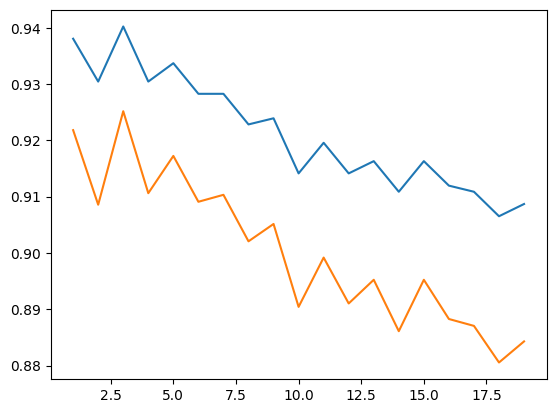

In [8]:
accuracy_scores = []
f1_scores = []

for k in range(1, 20):
    knn = KNNClassifier(k, 5, euclidean_distance)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy_scores.append(accuracy_score(y_pred, y_test))
    f1_scores.append(f1_score(y_pred, y_test))

plt.plot(range(1, 20), accuracy_scores)
plt.plot(range(1, 20), f1_scores)
plt.show()

# MinMaxScaler

In [9]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0]

(0.04481792717086835,
 0.12549019607843137,
 0.0,
 0.032,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.06618407445708377,
 0.0,
 0.0,
 0.0,
 0.016,
 0.0,
 0.1419141914191419,
 0.10293333333333334,
 0.0,
 0.08640864086408641,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.02395467701213129,
 0.0,
 0.0,
 0.0025020426690876077,
 0.006007208650380457,
 0.01748737373737374,
 1.0)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 0.2, 42)

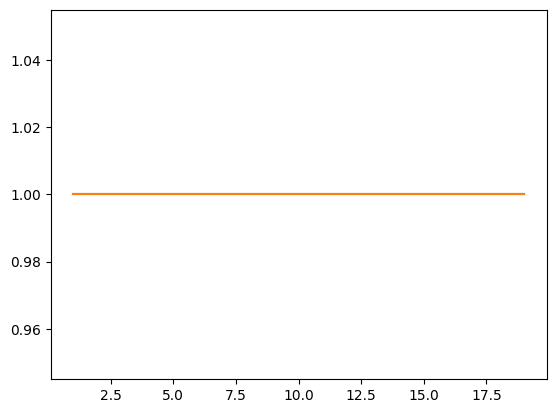

In [11]:
accuracy_scores = []
f1_scores = []

for k in range(1, 20):
    knn = KNNClassifier(k, 5, euclidean_distance)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy_scores.append(accuracy_score(y_pred, y_test))
    f1_scores.append(f1_score(y_pred, y_test))

plt.plot(range(1, 20), accuracy_scores)
plt.plot(range(1, 20), f1_scores)
plt.show()

idk why accuracy is 1.0

# StandardScaler

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[0]

(0.3308849030129258,
 0.7128587736400362,
 -0.046899583822374885,
 0.011564710589097318,
 -0.3502661763707442,
 -0.2917938862249028,
 -0.26256155849148305,
 -0.32330235861696616,
 -0.3713643856414437,
 -0.29685952662487414,
 0.11408733254931307,
 -0.31205520602358944,
 -0.17492716667747027,
 -0.19011440518098974,
 0.08617143631022914,
 -0.3211354140662565,
 2.0812066359658967,
 0.15090537439911647,
 -0.1678931128521786,
 0.12512839789747224,
 -0.11817150892988554,
 -0.29020920285990076,
 -0.2129943883521665,
 -0.32881466917148233,
 -0.2992399339832851,
 -0.22789481188682262,
 -0.23183015604585316,
 -0.16673144993700473,
 -0.22523951812730955,
 -0.1605393069357143,
 -0.1432120208358773,
 -0.17492025723498275,
 -0.1452151478697517,
 -0.1980673897457466,
 -0.2421302224436611,
 -0.32345561317087573,
 -0.059836236937887186,
 -0.18091134406612605,
 -0.18530384922421805,
 -0.12090468438216595,
 -0.17259996190688398,
 -0.20599311373727341,
 -0.12734332044952554,
 -0.2977762087249436,
 -0.19738

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 0.2, 42)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


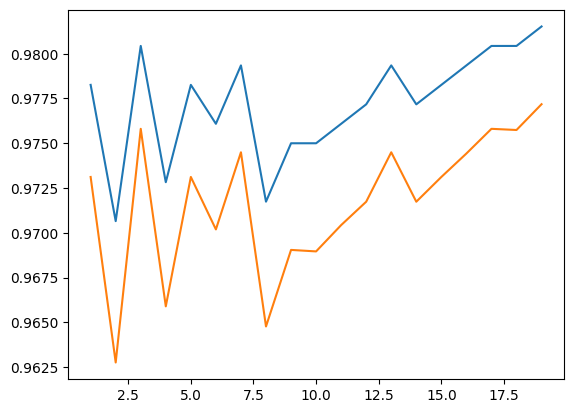

In [15]:
accuracy_scores = []
f1_scores = []

for k in range(1, 20):
    print(k)
    knn = KNNClassifier(k, 5, euclidean_distance)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)

    accuracy_scores.append(accuracy_score(y_pred, y_test))
    f1_scores.append(f1_score(y_pred, y_test))

plt.plot(range(1, 20), accuracy_scores)
plt.plot(range(1, 20), f1_scores)
plt.show()